# import libraries

In [1]:
import os
import math

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import RobustScaler

from sklearn.model_selection import train_test_split

# load data

In [2]:
df = pd.read_csv(r"../data/GPC_dataset.csv")
df.head()

,liquid/Binder,Cement (kg/m3),GGBS (kg/m3),Fly ash (kg/m3),Silica fume (kg/m3),Alkaline Solution (kg/m3),Fine aggregate (Kg/m3),Coarse aggregate (Kg/m3),Superplasticizer (kg/m3),Additional Water (Kg/m3),NaOH (Molarity),SS/SH Ratio,Age,Curing Temp (C),Compressive_strength,CO2 Emission (Kg/m3)
0,0.55,0.0,108.0,252.0,0.0,198.0,770.0,1090.0,0.0,0.0,8.0,2.5,7.0,30.0,33.83,101.13
1,0.55,0.0,108.0,252.0,0.0,198.0,770.0,1090.0,0.0,0.0,8.0,2.5,28.0,30.0,41.10,101.13
2,0.55,0.0,108.0,252.0,0.0,198.0,770.0,1090.0,0.0,0.0,8.0,2.5,7.0,60.0,34.53,101.13
3,0.55,0.0,108.0,252.0,0.0,198.0,770.0,1090.0,0.0,0.0,8.0,2.5,28.0,60.0,41.27,101.13
4,0.55,0.0,72.0,288.0,0.0,198.0,770.0,1090.0,0.0,0.0,8.0,2.5,7.0,30.0,30.87,99.41


In [3]:
df = df[(df["Cement (kg/m3)"] == 0) & (df["Alkaline Solution (kg/m3)"] > 0)]

df = df[df["Age"] == 28].reset_index(drop=True)

df.shape

(658, 16)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 658 entries, 0 to 657
Data columns (total 16 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   liquid/Binder              658 non-null    float64
 1   Cement (kg/m3)             658 non-null    float64
 2   GGBS (kg/m3)               658 non-null    float64
 3   Fly ash (kg/m3)            658 non-null    float64
 4   Silica fume (kg/m3)        658 non-null    float64
 5   Alkaline Solution (kg/m3)  658 non-null    float64
 6   Fine aggregate (Kg/m3)     642 non-null    float64
 7   Coarse aggregate (Kg/m3)   642 non-null    float64
 8   Superplasticizer (kg/m3)   658 non-null    float64
 9   Additional Water (Kg/m3)   658 non-null    float64
 10  NaOH (Molarity)            658 non-null    float64
 11  SS/SH Ratio                658 non-null    float64
 12  Age                        658 non-null    float64
 13  Curing Temp (C)            658 non-null    float64

# analysis 

In [5]:
df.isnull().sum()

liquid/Binder                 0
Cement (kg/m3)                0
GGBS (kg/m3)                  0
Fly ash (kg/m3)               0
Silica fume (kg/m3)           0
Alkaline Solution (kg/m3)     0
Fine aggregate (Kg/m3)       16
Coarse aggregate (Kg/m3)     16
Superplasticizer (kg/m3)      0
Additional Water (Kg/m3)      0
NaOH (Molarity)               0
SS/SH Ratio                   0
Age                           0
Curing Temp (C)               0
Compressive_strength          0
CO2 Emission (Kg/m3)          0
dtype: int64

In [6]:
df = df.dropna().reset_index(drop=True)
df.shape

(642, 16)

In [7]:
df.describe()

,liquid/Binder,Cement (kg/m3),GGBS (kg/m3),Fly ash (kg/m3),Silica fume (kg/m3),Alkaline Solution (kg/m3),Fine aggregate (Kg/m3),Coarse aggregate (Kg/m3),Superplasticizer (kg/m3),Additional Water (Kg/m3),NaOH (Molarity),SS/SH Ratio,Age,Curing Temp (C),Compressive_strength,CO2 Emission (Kg/m3)
count,642.000000,642.0,642.000000,642.000000,642.000000,642.000000,642.000000,642.000000,642.000000,642.000000,642.000000,642.000000,642.0,642.000000,642.000000,642.000000
mean,0.498901,0.0,144.776449,276.879844,0.186916,183.497223,681.751187,1072.849016,5.490265,24.568972,10.708723,2.082560,28.0,44.671340,40.233866,134.594433
std,0.138176,0.0,158.949111,145.325772,2.949806,40.357185,127.736081,201.432374,7.071218,43.582095,3.367976,0.726006,0.0,23.600142,14.689624,35.636288
min,0.191753,0.0,0.000000,0.000000,0.000000,74.400000,320.000000,525.400000,0.000000,0.000000,2.000000,0.586957,28.0,6.000000,0.550000,38.230240
25%,0.427778,0.0,0.000000,180.000000,0.000000,150.000000,547.500000,950.000000,0.000000,0.000000,8.000000,1.419753,28.0,25.000000,31.210000,106.396600
50%,0.450882,0.0,108.000000,300.000000,0.000000,179.000000,702.335000,1120.000000,1.250000,0.000000,10.000000,2.499903,28.0,30.000000,38.508650,132.649980
75%,0.570000,0.0,225.000000,400.000000,0.000000,210.000000,774.000000,1226.000000,10.500000,35.000000,14.000000,2.500000,28.0,60.000000,50.467500,156.211854
max,1.288000,0.0,560.000000,550.000000,60.000000,340.000000,920.000000,1567.000000,47.000000,170.000000,23.000000,4.504587,28.0,100.000000,78.420000,244.359741


In [8]:
# correlation

In [9]:
corr = df.corr(numeric_only=True)
corr

,liquid/Binder,Cement (kg/m3),GGBS (kg/m3),Fly ash (kg/m3),Silica fume (kg/m3),Alkaline Solution (kg/m3),Fine aggregate (Kg/m3),Coarse aggregate (Kg/m3),Superplasticizer (kg/m3),Additional Water (Kg/m3),NaOH (Molarity),SS/SH Ratio,Age,Curing Temp (C),Compressive_strength,CO2 Emission (Kg/m3)
liquid/Binder,1.000000,NaN,0.038142,-0.163574,0.028536,0.638646,0.319739,-0.475510,0.092644,0.581299,-0.243873,0.164850,NaN,-0.197570,-0.043778,0.254527
Cement (kg/m3),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
GGBS (kg/m3),0.038142,NaN,1.000000,-0.864944,-0.057806,0.079407,0.128910,-0.328857,-0.132102,0.308981,-0.149039,0.097411,NaN,-0.129312,0.302002,-0.002733
Fly ash (kg/m3),-0.163574,NaN,-0.864944,1.000000,0.053767,0.026194,-0.256838,0.153992,0.034706,-0.155171,0.130568,-0.126036,NaN,0.141867,-0.275142,0.029831
Silica fume (kg/m3),0.028536,NaN,-0.057806,0.053767,1.000000,0.029621,0.083593,-0.038705,0.166125,0.034120,0.036894,0.028667,NaN,0.068113,0.060411,0.157258
Alkaline Solution (kg/m3),0.638646,NaN,0.079407,0.026194,0.029621,1.000000,0.080921,-0.371115,0.137085,0.140298,-0.263632,0.079417,NaN,-0.082350,0.009129,0.514877
Fine aggregate (Kg/m3),0.319739,NaN,0.128910,-0.256838,0.083593,0.080921,1.000000,-0.572372,0.487085,0.212210,-0.032421,0.287038,NaN,-0.000935,0.037358,0.205793
Coarse aggregate (Kg/m3),-0.475510,NaN,-0.328857,0.153992,-0.038705,-0.371115,-0.572372,1.000000,-0.175321,-0.723579,0.219719,-0.318947,NaN,0.220889,-0.068569,-0.099836
Superplasticizer (kg/m3),0.092644,NaN,-0.132102,0.034706,0.166125,0.137085,0.487085,-0.175321,1.000000,-0.149146,-0.026330,0.283056,NaN,0.113571,0.065621,0.465184
Additional Water (Kg/m3),0.581299,NaN,0.308981,-0.155171,0.034120,0.140298,0.212210,-0.723579,-0.149146,1.000000,-0.213919,0.198539,NaN,-0.266227,0.015514,-0.145254


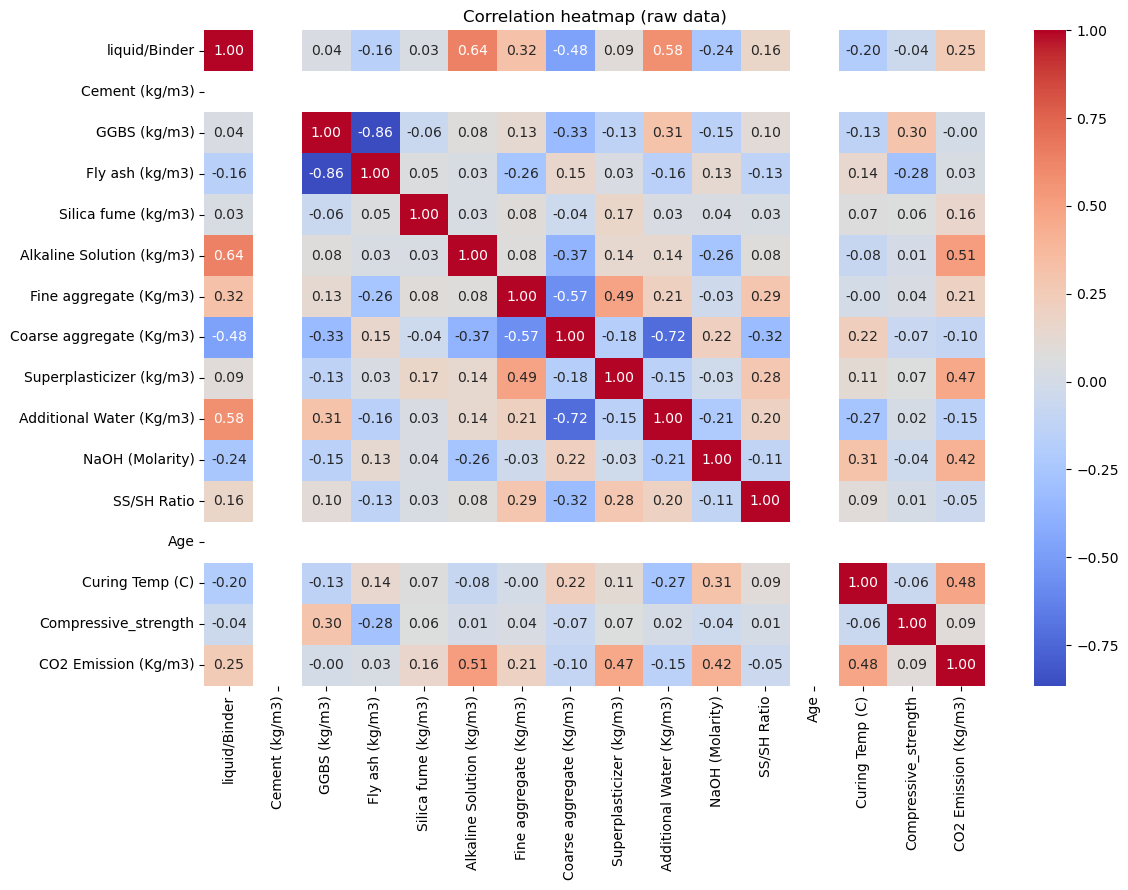

In [10]:
plt.figure(figsize=(12, 9))
sns.heatmap(corr, cmap="coolwarm", annot=True, fmt=".2f")
plt.title("Correlation heatmap (raw data)")
plt.tight_layout()
plt.show()

In [11]:
df.corr(numeric_only=True)["Compressive_strength"].sort_values(ascending=False)

Compressive_strength         1.000000
GGBS (kg/m3)                 0.302002
CO2 Emission (Kg/m3)         0.091564
Superplasticizer (kg/m3)     0.065621
Silica fume (kg/m3)          0.060411
Fine aggregate (Kg/m3)       0.037358
Additional Water (Kg/m3)     0.015514
SS/SH Ratio                  0.010975
Alkaline Solution (kg/m3)    0.009129
NaOH (Molarity)             -0.040405
liquid/Binder               -0.043778
Curing Temp (C)             -0.058390
Coarse aggregate (Kg/m3)    -0.068569
Fly ash (kg/m3)             -0.275142
Cement (kg/m3)                    NaN
Age                               NaN
Name: Compressive_strength, dtype: float64

In [12]:
df.corr(numeric_only=True)["CO2 Emission (Kg/m3)"].sort_values(ascending=False)

CO2 Emission (Kg/m3)         1.000000
Alkaline Solution (kg/m3)    0.514877
Curing Temp (C)              0.476380
Superplasticizer (kg/m3)     0.465184
NaOH (Molarity)              0.415509
liquid/Binder                0.254527
Fine aggregate (Kg/m3)       0.205793
Silica fume (kg/m3)          0.157258
Compressive_strength         0.091564
Fly ash (kg/m3)              0.029831
GGBS (kg/m3)                -0.002733
SS/SH Ratio                 -0.049825
Coarse aggregate (Kg/m3)    -0.099836
Additional Water (Kg/m3)    -0.145254
Cement (kg/m3)                    NaN
Age                               NaN
Name: CO2 Emission (Kg/m3), dtype: float64

In [13]:
# scatter dependency

In [14]:
labels = ["CO2 Emission (Kg/m3)", "Compressive_strength"]
features = df.drop(columns=labels)

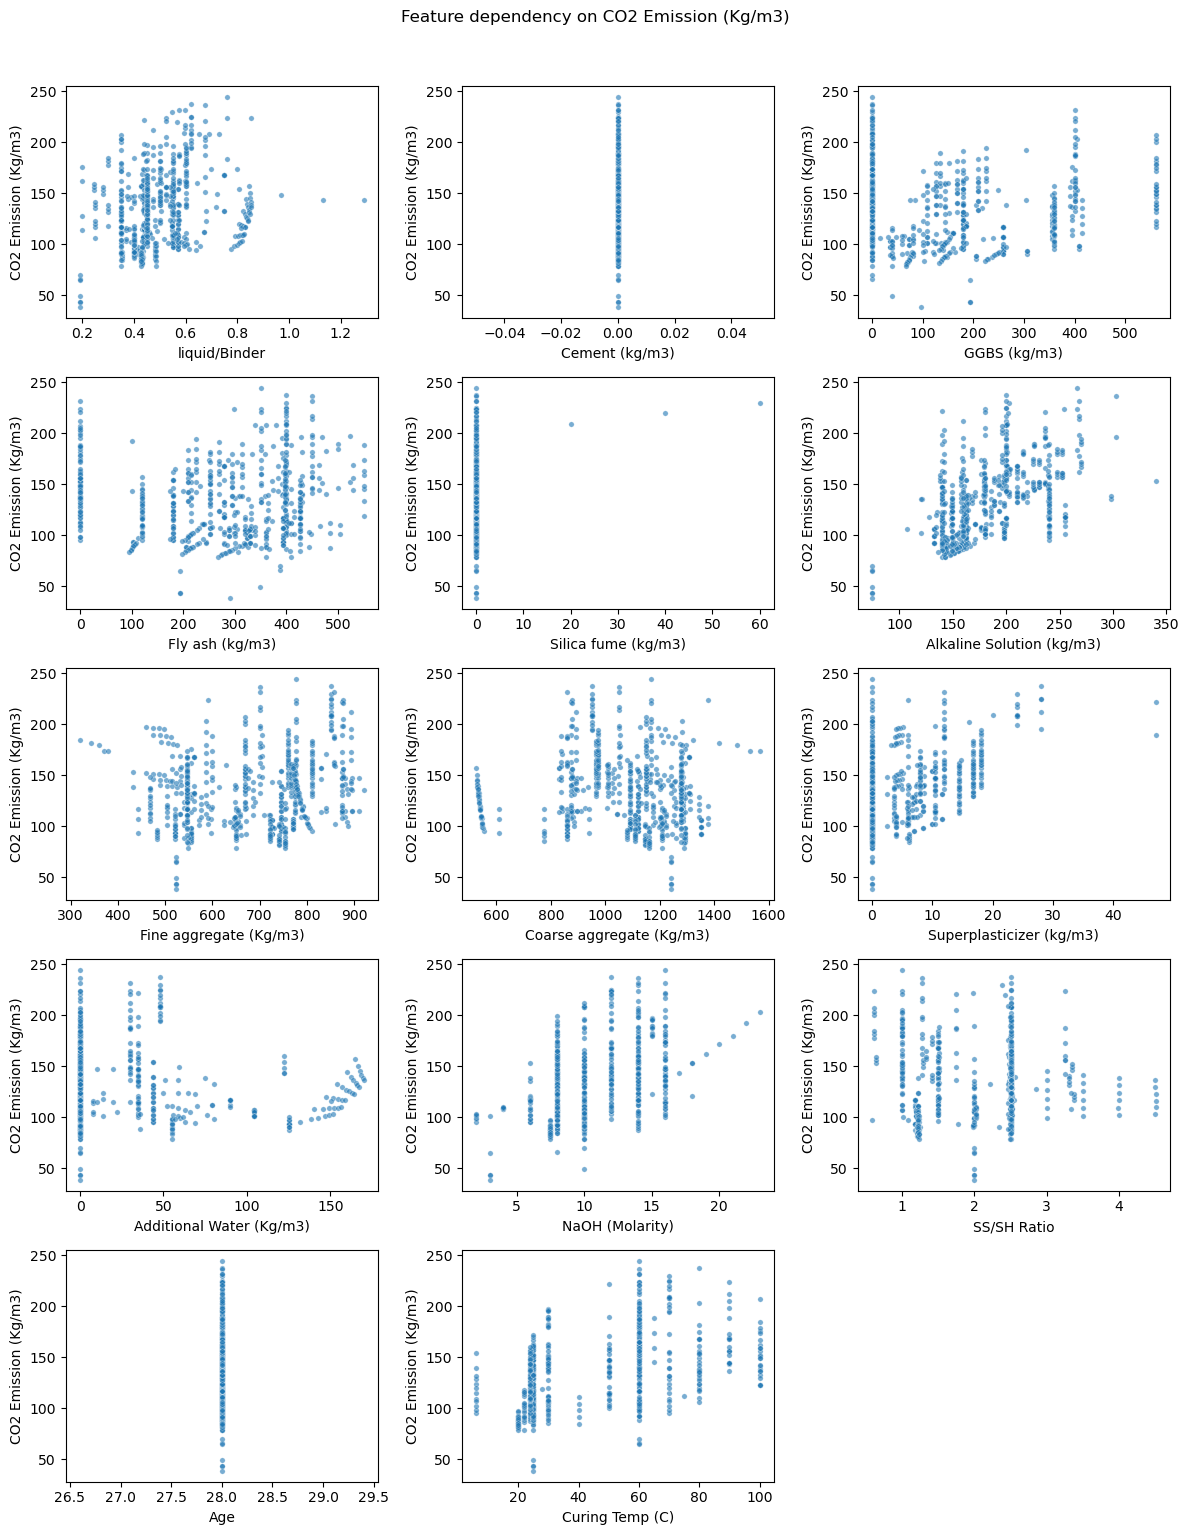

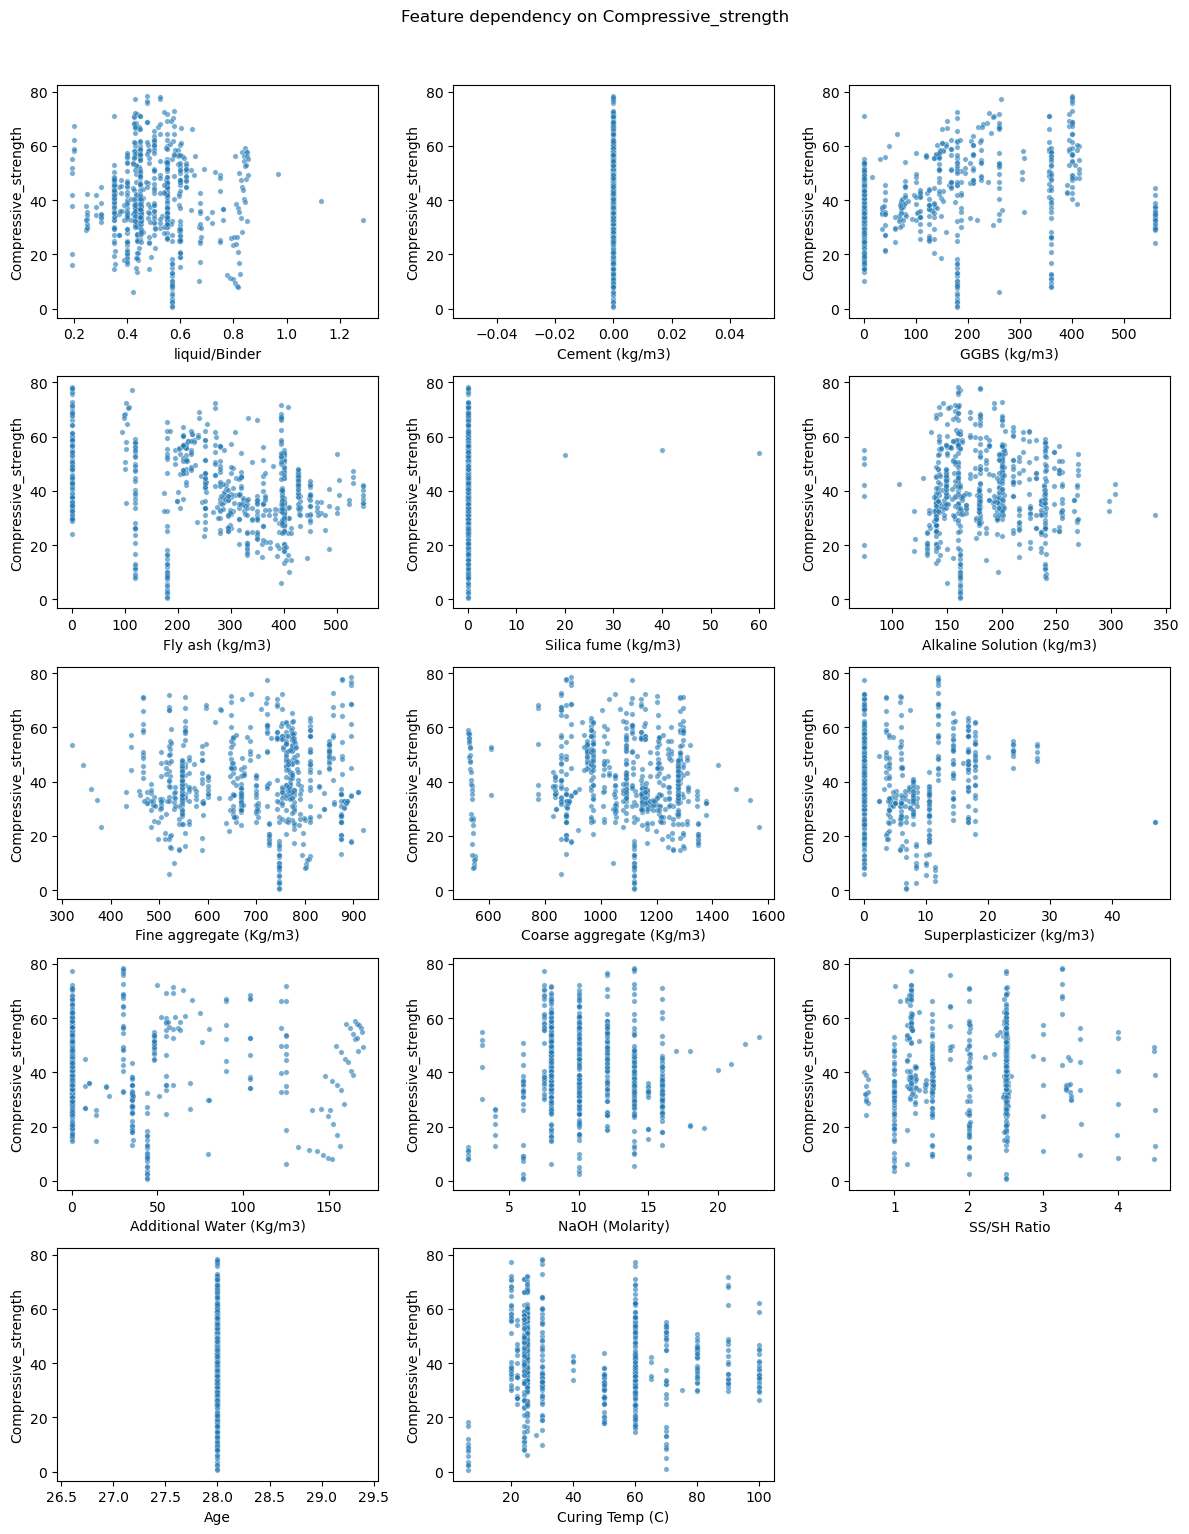

In [15]:
n_cols = 3

for target in labels:
    n_rows = math.ceil(len(features.columns) / n_cols)
    plt.figure(figsize=(4 * n_cols, 3 * n_rows))
    for i, col in enumerate(features.columns, 1):
        plt.subplot(n_rows, n_cols, i)
        sns.scatterplot(data=df, x=col, y=target, s=15, alpha=0.6)
        plt.xlabel(col)
        plt.ylabel(target)
    plt.suptitle(f"Feature dependency on {target}", y=1.02)
    plt.tight_layout()
    plt.show()

In [16]:
# Feature engineering

In [17]:
binder_cols = ["Cement (kg/m3)", "GGBS (kg/m3)", "Fly ash (kg/m3)", "Silica fume (kg/m3)"]
df["Total_Binder"] = df[binder_cols].sum(axis=1)

df["Water_to_Binder"] = df["Additional Water (Kg/m3)"] / df["Total_Binder"]
df["SP_ratio"] = df["Superplasticizer (kg/m3)"] / df["Total_Binder"]

df.head(2)

,liquid/Binder,Cement (kg/m3),GGBS (kg/m3),Fly ash (kg/m3),Silica fume (kg/m3),Alkaline Solution (kg/m3),Fine aggregate (Kg/m3),Coarse aggregate (Kg/m3),Superplasticizer (kg/m3),Additional Water (Kg/m3),NaOH (Molarity),SS/SH Ratio,Age,Curing Temp (C),Compressive_strength,CO2 Emission (Kg/m3),Total_Binder,Water_to_Binder,SP_ratio
0,0.55,0.0,108.0,252.0,0.0,198.0,770.0,1090.0,0.0,0.0,8.0,2.5,28.0,30.0,41.10,101.13,360.0,0.0,0.0
1,0.55,0.0,108.0,252.0,0.0,198.0,770.0,1090.0,0.0,0.0,8.0,2.5,28.0,60.0,41.27,101.13,360.0,0.0,0.0


In [18]:
# Distribution analysis

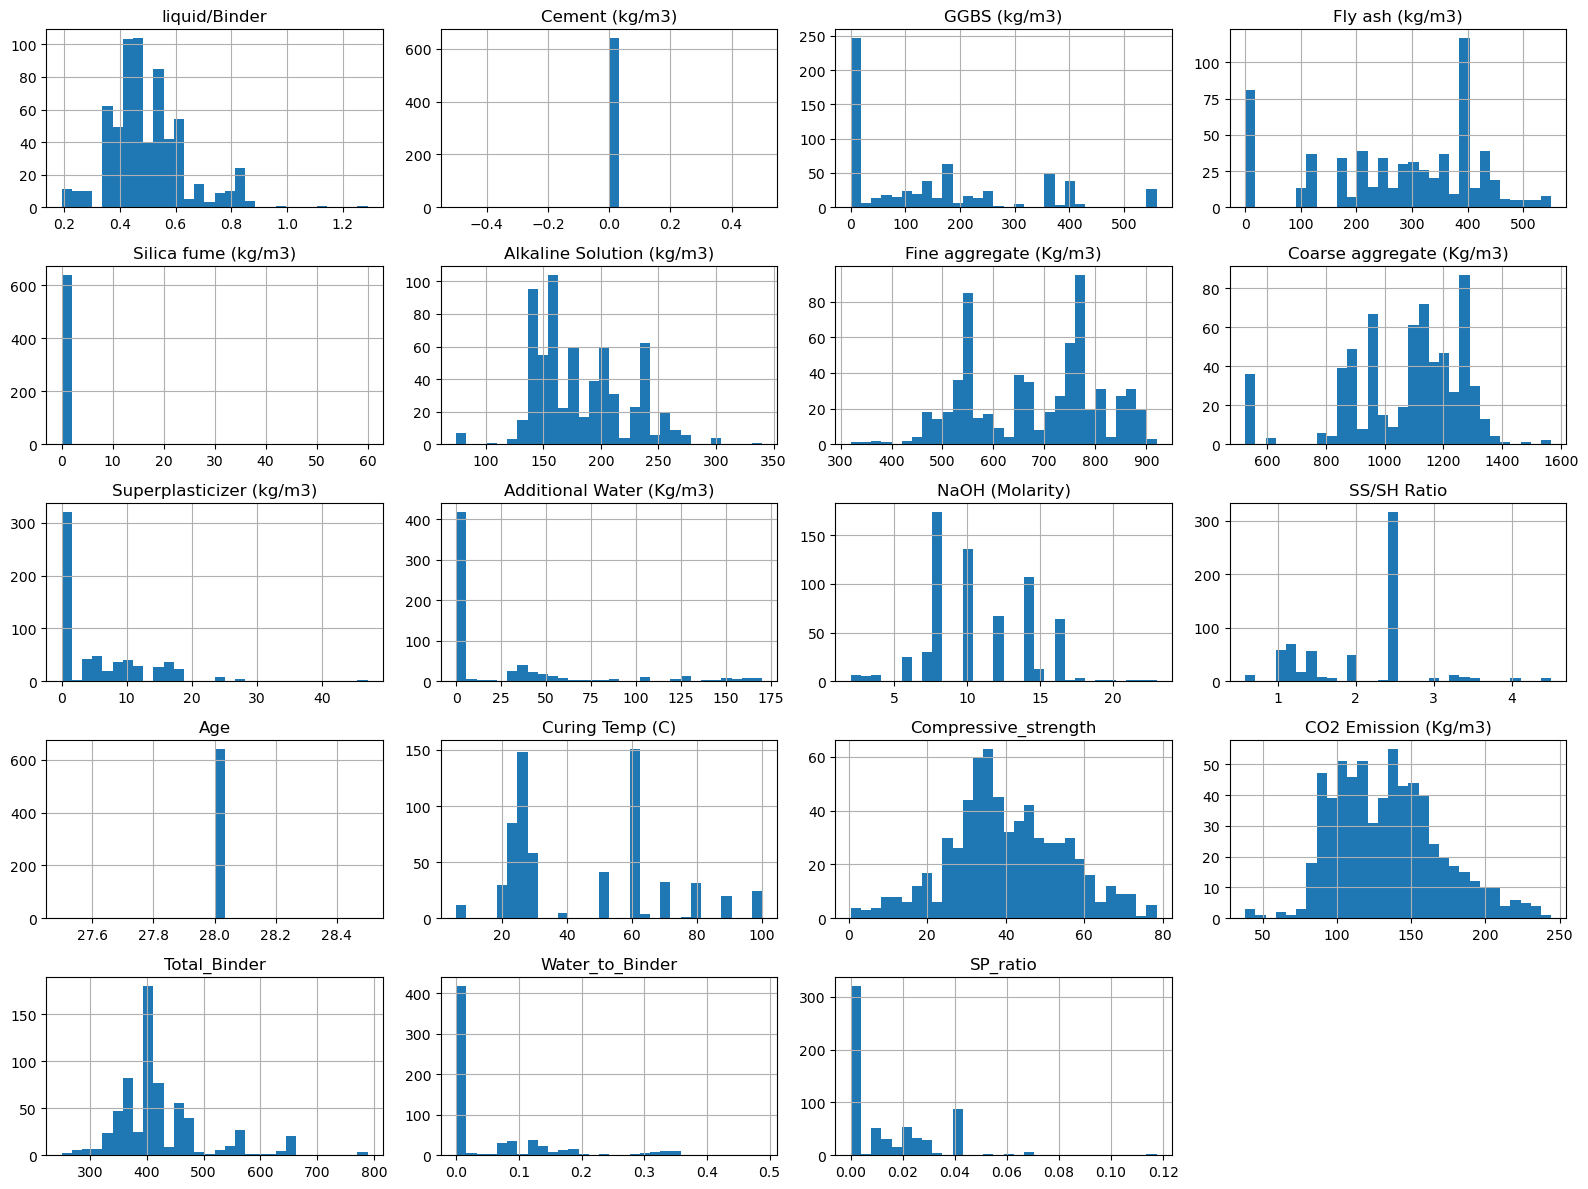

In [19]:
df.hist(figsize=(16, 12), bins=30)
plt.tight_layout()
plt.show()

In [20]:
# Outliers

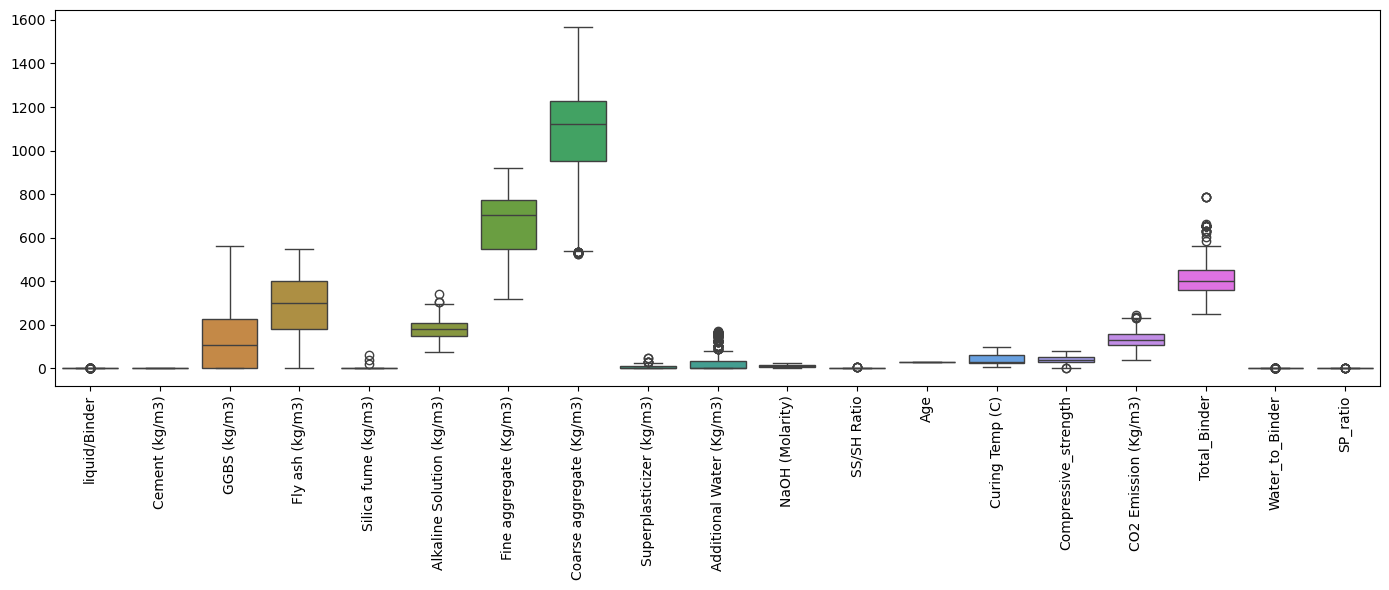

In [21]:
plt.figure(figsize=(14, 6))
sns.boxplot(data=df.select_dtypes("number"))
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [22]:
# Preprocessing

In [23]:
y = df[["CO2 Emission (Kg/m3)", "Compressive_strength"]]
features = df.drop(columns=y.columns)

scale_features = features.columns.tolist()
scale_features

['liquid/Binder',
 'Cement (kg/m3)',
 'GGBS (kg/m3)',
 'Fly ash (kg/m3)',
 'Silica fume (kg/m3)',
 'Alkaline Solution (kg/m3)',
 'Fine aggregate (Kg/m3)',
 'Coarse aggregate (Kg/m3)',
 'Superplasticizer (kg/m3)',
 'Additional Water (Kg/m3)',
 'NaOH (Molarity)',
 'SS/SH Ratio',
 'Age',
 'Curing Temp (C)',
 'Total_Binder',
 'Water_to_Binder',
 'SP_ratio']

In [24]:
X_train, X_test, y_train, y_test = train_test_split(
    features, y, test_size=0.2, random_state=42
)
X_train.shape, X_test.shape

((513, 17), (129, 17))

In [25]:
preprocessor = RobustScaler()
X_train_scaled = preprocessor.fit_transform(X_train)
X_test_scaled = preprocessor.transform(X_test)
X_train_scaled.shape, X_test_scaled.shape

((513, 17), (129, 17))

In [26]:
prepared_cols = preprocessor.get_feature_names_out()
X_train_scaled = pd.DataFrame(X_train_scaled, columns=prepared_cols, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=prepared_cols, index=X_test.index)
X_train_scaled.head()

,liquid/Binder,Cement (kg/m3),GGBS (kg/m3),Fly ash (kg/m3),Silica fume (kg/m3),Alkaline Solution (kg/m3),Fine aggregate (Kg/m3),Coarse aggregate (Kg/m3),Superplasticizer (kg/m3),Additional Water (Kg/m3),NaOH (Molarity),SS/SH Ratio,Age,Curing Temp (C),Total_Binder,Water_to_Binder,SP_ratio
29,-0.006197,0.0,1.360000,-1.363636,0.0,0.116667,-0.066440,0.518382,0.0,0.000000,1.000000,8.000005e-10,0.0,0.000000,0.155556,0.000000,0.0
148,0.685349,0.0,-0.066667,0.327273,0.0,1.266667,-0.890716,0.238971,0.0,0.000000,-0.666667,-6.340508e-03,0.0,-0.142857,0.722222,0.000000,0.0
612,4.772168,0.0,-0.102222,-0.454545,0.0,0.350000,0.114719,0.191176,0.0,3.485714,0.666667,-9.257143e-01,0.0,-0.171429,-1.277778,4.892231,0.0
210,-0.136234,0.0,-0.480000,0.743182,0.0,0.350000,-0.769792,0.158309,0.0,0.000000,-0.333333,-9.257143e-01,0.0,1.714286,0.705556,0.000000,0.0
299,-1.060520,0.0,2.008889,-1.363636,0.0,-0.183333,-0.147962,0.136029,0.0,0.000000,0.666667,7.476923e-01,0.0,1.428571,1.777778,0.000000,0.0


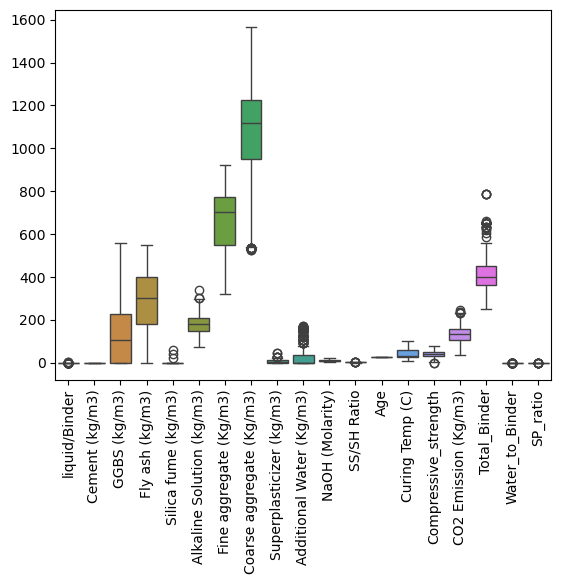

In [27]:
plt.figure()
sns.boxplot(data=df.select_dtypes("number"))
plt.xticks(rotation=90)
plt.show()


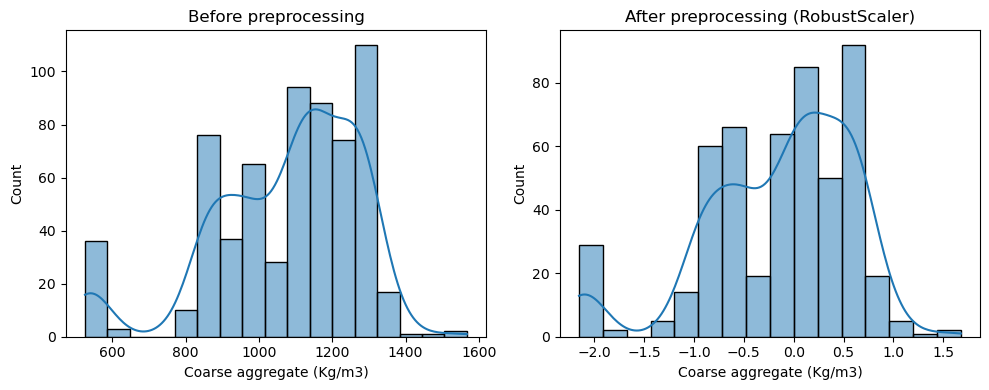

In [29]:
col = "Coarse aggregate (Kg/m3)"

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
sns.histplot(df[col], kde=True, ax=axes[0])
axes[0].set_title("Before preprocessing")
axes[0].set_xlabel(col)

sns.histplot(X_train_scaled[col], kde=True, ax=axes[1])
axes[1].set_title("After preprocessing (RobustScaler)")
axes[1].set_xlabel(col)
plt.tight_layout()
plt.show()

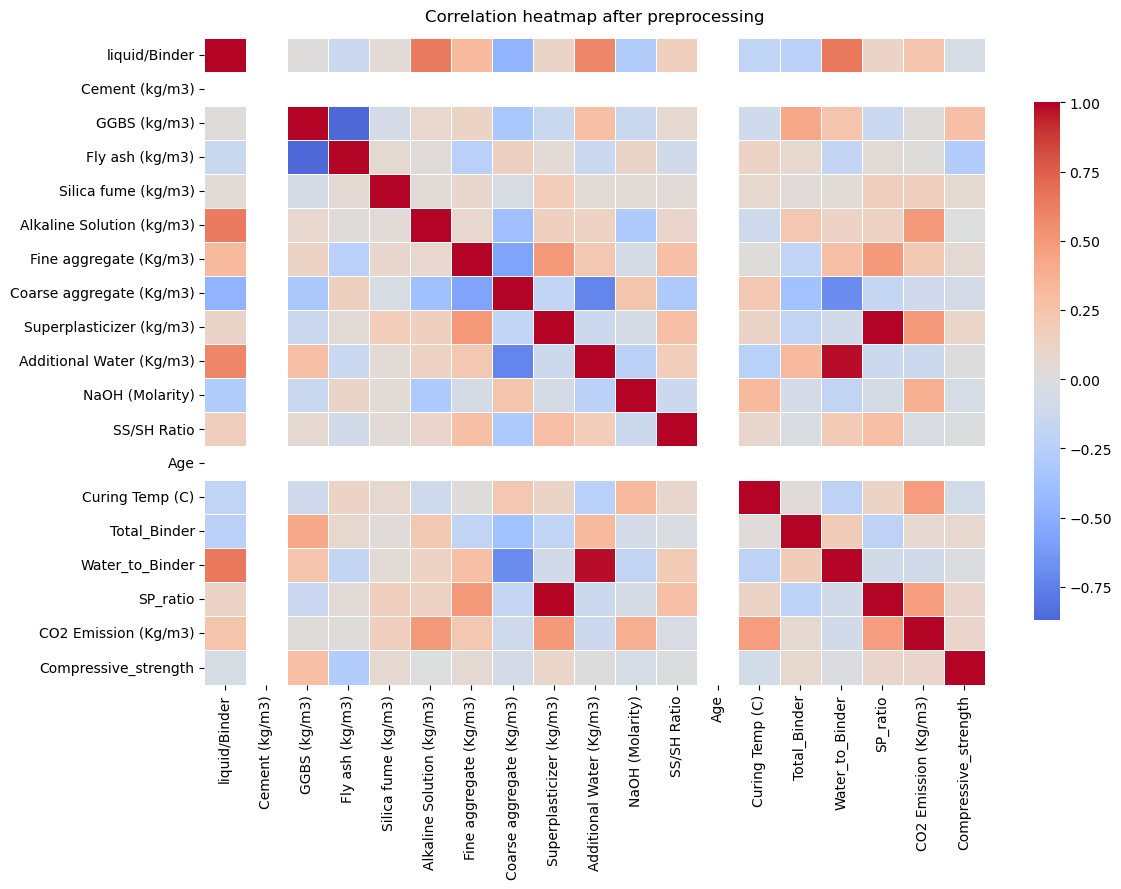

In [30]:
heatmap_df = pd.concat([X_train_scaled, y_train], axis=1)
corr = heatmap_df.corr()

plt.figure(figsize=(12, 9))
sns.heatmap(corr, cmap="coolwarm", center=0, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title("Correlation heatmap after preprocessing", pad=12)
plt.tight_layout()
plt.show()

In [32]:
df.shape

(642, 19)

In [ ]:
# Save data

In [33]:
os.makedirs("../data", exist_ok=True)

train_data = pd.concat([X_train_scaled, y_train], axis=1)
test_data = pd.concat([X_test_scaled, y_test], axis=1)

train_data.to_csv("../data/train_preprocessed.csv", index=False)
test_data.to_csv("../data/test_preprocessed.csv", index=False)